In [1]:
# Import the required libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Load the training and test datasets
df_train = pd.read_csv('../data/fraudTrain.csv')
df_test = pd.read_csv('../data/fraudTest.csv')

In [3]:
# Display a preview of the dataframes
print("Train dataset shape:", df_train.shape)
print("Test dataset shape:", df_test.shape)

Train dataset shape: (1296675, 23)
Test dataset shape: (555719, 23)


In [4]:
# Display the names of all columns in the training dataset
print(df_train.columns)

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')


In [5]:
# Count missing values per column to identify incomplete data in the training dataset
missing = df_train.isna().sum()

# Filter and display only the columns that contain at least one missing value
print(missing[missing > 0])

Series([], dtype: int64)


In [6]:
# Convert the 'trans_date_trans_time' column from string to pandas datetime format
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])

# Verify that the data type has been updated correctly
df_train['trans_date_trans_time'].dtype

dtype('<M8[us]')

In [7]:
# Extract the transaction hour and store it in a new column    
df_train['trans_hour'] = df_train['trans_date_trans_time'].dt.hour

In [8]:
# Calculate the total number of fraud cases in the training and test datasets
train_total_fraud_cases = df_train['is_fraud'].sum()
test_total_fraud_cases = df_test['is_fraud'].sum()

# Display the total number of detected fraud cases in each dataset
print(f"Total fraud cases in the training dataset: {train_total_fraud_cases}")
print(f"Total fraud cases in the test dataset: {test_total_fraud_cases}")

# Calculate the fraud rate by dividing the number of positive cases by the total number of records
train_fraud_rate = train_total_fraud_cases / df_train.shape[0]
test_fraud_rate = test_total_fraud_cases / df_test.shape[0]

# Display the exact fraud percentage for both datasets
print(f"Fraud rate in the training dataset: {train_fraud_rate: .2%}")
print(f"Fraud rate in the test dataset: {test_fraud_rate: .2%}")

Total fraud cases in the training dataset: 7506
Total fraud cases in the test dataset: 2145
Fraud rate in the training dataset:  0.58%
Fraud rate in the test dataset:  0.39%


In [9]:
# Display the first 5 rows of the DataFrame to inspect its structure
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0


In [10]:
# Split the DataFrame into two subsets: fraudulent and legitimate transactions
train_fraud_transactions = df_train[df_train['is_fraud'] == 1]
train_legitimate_transactions = df_train[df_train['is_fraud'] == 0]

# Generate descriptive statistics
print("Summary statistics for fraudulent transactions:\n", train_fraud_transactions['amt'].describe())
print("Summary statistics for legitimate transactions:\n",train_legitimate_transactions['amt'].describe())

Summary statistics for fraudulent transactions:
 count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64
Summary statistics for legitimate transactions:
 count    1.289169e+06
mean     6.766711e+01
std      1.540080e+02
min      1.000000e+00
25%      9.610000e+00
50%      4.728000e+01
75%      8.254000e+01
max      2.894890e+04
Name: amt, dtype: float64


In [11]:
# Calculate the mean and median transaction amount grouped by purchase category and transaction type 
df_train.groupby(['category', 'is_fraud'])['amt'].agg(['mean', 'median'])

mean   median
category       is_fraud                     
entertainment  0          63.118913   50.550
               1         503.535579  498.860
food_dining    0          50.972816   41.930
               1         120.076954  119.420
gas_transport  0          63.675782   62.930
               1          12.288204   10.645
grocery_net    0          53.792817   50.990
               1          12.162836   12.365
grocery_pos    0         114.172234  104.550
               1         311.989616  309.980
health_fitness 0          54.234775   42.940
               1          20.248421   19.800
home           0          57.949319   48.170
               1         257.432626  252.160
kids_pets      0          57.620386   47.240
               1          18.121674   19.520
misc_net       0          70.359176    9.680
               1         797.012852  792.330
misc_pos       0          62.401757   13.950
               1         218.284080    8.955
personal_care  0          48.020643   32.670
               1          26.170545   20.825
shopping_net   0          72.142606    8.300
               1         999.254939  995.570
shopping_pos   0          73.977575    7.710
               1         876.921815  867.760
travel         0         111.798920    6.250
               1           9.064569    9.735

In [12]:
# Count fraud cases by merchant category and sort them in descending order
frauds_by_category = train_fraud_transactions['category'].value_counts().sort_values(ascending=False)

frauds_by_category

category
grocery_pos       1743
shopping_net      1713
misc_net           915
shopping_pos       843
gas_transport      618
misc_pos           250
kids_pets          239
entertainment      233
personal_care      220
home               198
food_dining        151
grocery_net        134
health_fitness     133
travel             116
Name: count, dtype: int64

In [13]:
# Count legitimate transactions by category to verify the number of transactions in each one
legitimate_transactions_by_category = train_legitimate_transactions['category'].value_counts().sort_values(ascending=False)
legitimate_transactions_by_category

category
gas_transport     131041
home              122917
grocery_pos       121895
shopping_pos      115829
kids_pets         112796
shopping_net       95830
entertainment      93781
food_dining        91310
personal_care      90538
health_fitness     85746
misc_pos           79405
misc_net           62372
grocery_net        45318
travel             40391
Name: count, dtype: int64

In [14]:
# Count the total number of fraud cases by gender
frauds_by_gender = train_fraud_transactions['gender'].value_counts().sort_values(ascending=False)

# Generate a cross-tabulation showing the exact fraud rate for each gender
pd.crosstab(df_train['gender'], df_train['is_fraud'], normalize='index') * 100

is_fraud,0,1
gender,,
F,99.473842,0.526158
M,99.357375,0.642625


In [15]:
# Group and count fraud cases by hour of the day
fraud_cases_by_hour = train_fraud_transactions['trans_hour'].value_counts().sort_index()
fraud_hours = fraud_cases_by_hour.index
fraud_case_counts = fraud_cases_by_hour.values
print(f"Fraud Cases by Hour of the Day:\n{fraud_cases_by_hour}")

Fraud Cases by Hour of the Day:
trans_hour
0      635
1      658
2      625
3      609
4       46
5       60
6       40
7       56
8       49
9       47
10      40
11      42
12      67
13      80
14      86
15      79
16      76
17      78
18      81
19      81
20      62
21      74
22    1931
23    1904
Name: count, dtype: int64


In [16]:
# Group and count legitimate transactions by hour of the day
legitimate_transactions_by_hour = train_legitimate_transactions['trans_hour'].value_counts().sort_index()
legitimate_hours = legitimate_transactions_by_hour.index
legitimate_transaction_counts = legitimate_transactions_by_hour.values
print(f"Legitimate Transactions by Hour of the Day:\n{legitimate_transactions_by_hour}")


Legitimate Transactions by Hour of the Day:
trans_hour
0     41867
1     42211
2     42031
3     42160
4     41817
5     42111
6     42260
7     42147
8     42456
9     42138
10    42231
11    42040
12    65190
13    65234
14    64799
15    65312
16    65650
17    65372
18    65970
19    65427
20    65036
21    65459
22    65051
23    65200
Name: count, dtype: int64


In [17]:
# Extract the day of the week for legitimate transactions and count their frequency
train_legitimate_transactions['trans_day'] = train_legitimate_transactions['trans_date_trans_time'].dt.day_name()
legitimate_transactions_by_day = train_legitimate_transactions['trans_day'].value_counts().sort_index()
print(f"Legitimate Transactions by Day:\n{legitimate_transactions_by_day}")

Legitimate Transactions by Day:
trans_day
Friday       151193
Monday       253100
Saturday     199730
Sunday       249363
Thursday     146277
Tuesday      159292
Wednesday    130214
Name: count, dtype: int64


In [18]:
# Extract the day of the week for fraudulent transactions and count their frequency
train_fraud_transactions['trans_day'] = train_fraud_transactions['trans_date_trans_time'].dt.day_name()
fraud_cases_by_day = train_fraud_transactions['trans_day'].value_counts().sort_index()
print(f"Fraud Cases by Day:\n{fraud_cases_by_day}")

Fraud Cases by Day:
trans_day
Friday       1079
Monday       1182
Saturday     1227
Sunday       1216
Thursday     1008
Tuesday       935
Wednesday     859
Name: count, dtype: int64


In [19]:
# Calculate the fraud rate for each day by dividing the number of fraud cases by the total number of transactions on that day
fraud_rate_by_day = fraud_cases_by_day / (fraud_cases_by_day + legitimate_transactions_by_day)

print(f'The fraud rate by day is: {fraud_rate_by_day.sort_values(ascending=False)}')

The fraud rate by day is: trans_day
Friday       0.007086
Thursday     0.006844
Wednesday    0.006554
Saturday     0.006106
Tuesday      0.005835
Sunday       0.004853
Monday       0.004648
Name: count, dtype: float64


### Key EDA Findings & Business Insights

* **High-Value Concentration:** Fraudulent transactions strictly concentrate on higher amounts compared to legitimate purchases, driving both the mean and median transaction values significantly higher.
* **Nighttime Pattern:** Overwhelming majority of fraudulent events occur between 22:00 and 03:00, establishing a clear high-risk temporal window.
* **Gender Disparity:** Male cardholders show a fraud rate of **0.64%**, which is roughly **22% higher** than female cardholders (**0.52%**).
* **Weekly Variation:** Fraud rates fluctuate throughout the week without following a strict "weekday vs. weekend" binary rule.
* **Category Penetration:** No merchant category is completely immune (all recorded at least one fraudulent transaction), though high-volume clusters concentrate in grocery_pos and shopping_net.

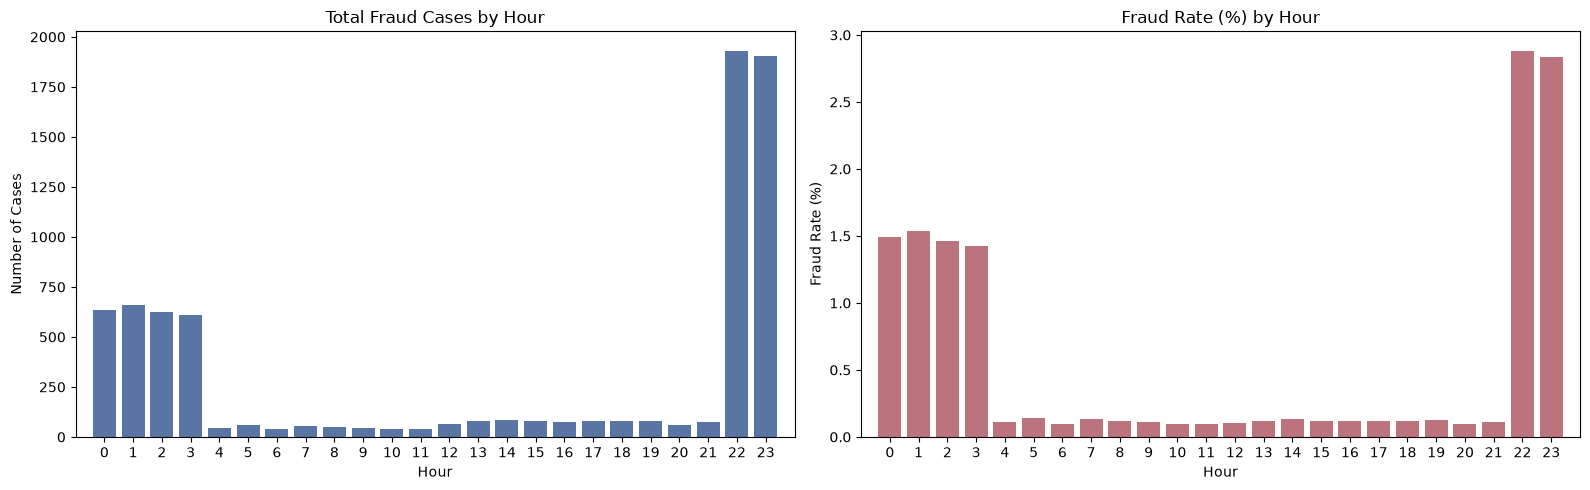

In [20]:
# Calculate the total transaction volume (legitimate + fraudulent) by hour of the day
total_transactions_by_hour = df_train['trans_hour'].value_counts().sort_index()

# Calculate the relative fraud rate by hour to avoid bias caused by absolute transaction volume
fraud_rate_by_hour = (fraud_cases_by_hour / total_transactions_by_hour) * 100

# Create a Matplotlib figure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left subplot: Bar chart showing the total number of fraud cases by hour
sns.barplot(ax=axes[0], x=fraud_cases_by_hour.index, y=fraud_cases_by_hour.values, color="#4c72b0")
axes[0].set_title("Total Fraud Cases by Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Number of Cases")
axes[0].set_xlim(-1, 24)

# Right subplot: Bar chart showing the fraud rate (%) by hour
sns.barplot(ax=axes[1], x=fraud_rate_by_hour.index, y=fraud_rate_by_hour.values, color="#C76875")
axes[1].set_title("Fraud Rate (%) by Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlim(-1, 24)

# Automatically adjust the spacing between subplots to prevent overlapping elements
plt.tight_layout()
plt.show()

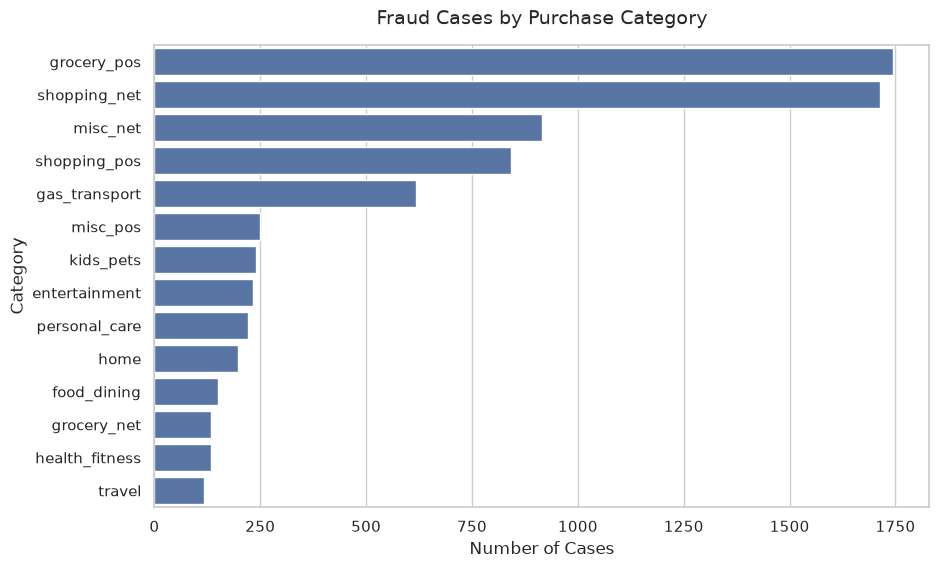

In [21]:
# Recalculate the number of fraud cases by category to ensure descending order in the chart
frauds_by_category = train_fraud_transactions['category'].value_counts()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a horizontal bar chart
sns.barplot(
    x=frauds_by_category.values,     
    y=frauds_by_category.index,      
    color="#4c72b0"
)

# Set the title and axis labels, including font size and padding
plt.title("Fraud Cases by Purchase Category", fontsize=14, pad=15)
plt.xlabel("Number of Cases", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.show()

/tmp/ipykernel_316/2197644874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


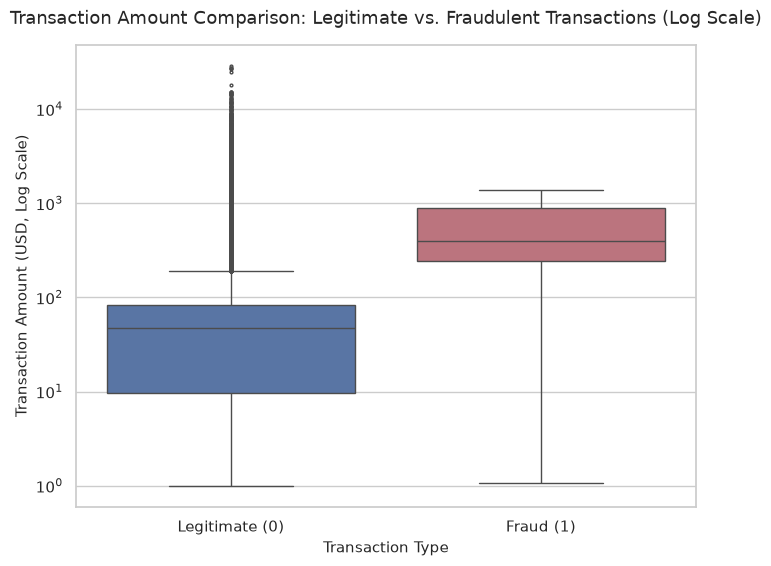

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create a box plot comparing transaction amounts ('amt') by transaction type ('is_fraud')
sns.boxplot(
    data=df_train,
    x='is_fraud',
    y='amt',
    palette=["#4c72b0", "#C76875"],
    fliersize=2
)

# Apply a logarithmic scale to the Y-axis to better visualize highly skewed distributions and outliers
plt.yscale('log')

# Replace the numeric X-axis values [0, 1] with user-friendly labels
plt.xticks(ticks=[0, 1], labels=['Legitimate (0)', 'Fraud (1)'])

# Set descriptive titles and axis labels with appropriate font sizes
plt.title("Transaction Amount Comparison: Legitimate vs. Fraudulent Transactions (Log Scale)", fontsize=13, pad=15)
plt.xlabel("Transaction Type", fontsize=11)
plt.ylabel("Transaction Amount (USD, Log Scale)", fontsize=11)

plt.show()